In [1]:
from collections.abc import Iterable
from typing import override

import dnnlpy
import dnnlpy.optim as dopt
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

print("PyTorch version: ", torch.__version__)



PyTorch version:  2.13.0+cpu


In [ ]:
"""
Adam 同时解决两个问题
    - 方向抖动的问题
    -  不同参数尺度不同的问题
"""

In [ ]:
"""
为什么需要Bias Correction
"""



Final theta: tensor([ 1.7586, -0.7498])
Final loss: 0.13107571005821228


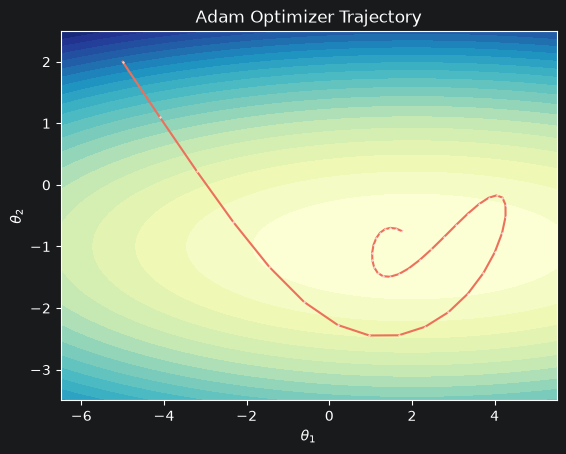

In [8]:
"""
AdamW的PyTorch实现
"""

class Adam(dopt.Optimizer):
    def __init__(self, params: Iterable[Tensor], lr: float = 1e-3, betas: tuple[float, float] = (0.9, 0.999),
                 eps: float = 1e-8,
                 weight_decay: float = 1e-2):
        super().__init__(params)
        self.lr = lr
        self.beta1 = betas[0]
        self.beta2 = betas[1]
        self.eps = eps
        self.weight_decay = weight_decay

        self.step_count = 0
        self.exp_avg = [torch.zeros_like(p) for p in self.params]
        self.exp_avg_sq = [torch.zeros_like(p) for p in self.params]

    @override
    @torch.no_grad()
    def step(self):
        self.step_count += 1

        for p, m, v in zip(self.params, self.exp_avg, self.exp_avg_sq):
            if p.grad is None:
                continue
            grad = p.grad
            if self.weight_decay > 0:
                grad = grad.add(p,alpha=self.weight_decay)
  
            m.mul_(self.beta1).add_(grad, alpha=1 - self.beta1)
            v.mul_(self.beta2).addcmul_(grad, grad, value=1 - self.beta2)

            bias_correction1 = 1 - self.beta1 ** self.step_count
            bias_correction2 = 1 - self.beta2 ** self.step_count

            m_hat = m / bias_correction1
            v_hat = v / bias_correction2

            p.addcdiv_(m_hat, v_hat.sqrt() + self.eps, value=-self.beta1)


def loss_fn(theta: Tensor) -> Tensor:
    x, y = theta[0], theta[1]
    return 0.1 * (x - 2) ** 2 + 2 * (y + 1) ** 2


theta = torch.tensor([-5.0, 2.0], requires_grad=True)
optimizer = Adam([theta], lr=0.25,weight_decay=0.0)
history = dopt.run_optimizer(optimizer, loss_fn, steps=40)

print('Final theta:', history[-1])
print('Final loss:', loss_fn(history[-1]).item())

#  可视化
x = torch.linspace(-6.5, 5.5, 200)
y = torch.linspace(-3.5, 2.5, 200)
X, Y = torch.meshgrid(x, y, indexing='ij')
Z = 0.1 * (X - 2) ** 2 + 2.0 * (Y + 1) ** 2

fig = plt.figure(1)
ax = fig.add_subplot(1, 1, 1)
ax.contourf(X, Y, Z, levels=25, cmap='YlGnBu')
ax.plot(
    history[:, 0],
    history[:, 1],
    color='#EC705B',
    marker='o',
    markerfacecolor='#EC705B',
    markeredgecolor='white',
    markersize=0.5,
)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_title('Adam Optimizer Trajectory')
plt.show()


